## Travel Planning Multi-Agent System
Supervisor agent coordinates Flight Agent and Hotel Agent.

In [ ]:
# Supervisor

# @tool
# Flight Agent 
#     >> Multiple Tools

# @tool
# Hotel Agent
#     >> Multiple Tools

In [ ]:
# >> Supervisor - prebuilt
#   >> create agent

In [ ]:
# >>  Supervisor Agent >> A , B , C , D
   
#     LLM As Agent
#     LLM/Agent with Tools 

In [2]:
#Configure AWS Bedrock credentials
import os

# ---------------------------
# AWS Bedrock LLM Setup
# ---------------------------
from langchain_aws import ChatBedrockConverse
model = ChatBedrockConverse(model_id= "anthropic.claude-3-sonnet-20240229-v1:0", #
                            region_name="us-east-1",
                            temperature=0.5, 
                            max_tokens=3000)

In [4]:
"""
Travel Planning Multi-Agent System
Supervisor agent coordinates Flight Agent and Hotel Agent.
"""

from langchain.tools import tool
from langchain.agents import create_agent

# ============================================================================
# Define low-level API tools
# ============================================================================

@tool
def search_flights(origin: str, destination: str, date: str) -> list[dict]:
   """Return stubbed list of flights."""
   return [
       {"flight": "SG101", "time": "08:00", "price": 350},
       {"flight": "SG202", "time": "11:00", "price": 300},
       {"flight": "SG303", "time": "18:00", "price": 420},
   ]


@tool
def book_flight(flight_id: str, passenger: str) -> str:
   """Book a flight."""
   return f"Flight {flight_id} booked for {passenger}"


@tool
def search_hotels(city: str, checkin: str, nights: int) -> list[dict]:
   """Return stubbed list of hotels."""
   return [
       {"name": "Marina Bay Hotel", "price": 180},
       {"name": "City Center Inn", "price": 120},
       {"name": "Harbor View Suites", "price": 150},
   ]


@tool
def book_hotel(hotel_name: str, nights: int, guest: str) -> str:
   """Book a hotel."""
   return f"Hotel '{hotel_name}' booked for {guest} for {nights} nights"


# ============================================================================
# Create specialized sub-agents
# ============================================================================


# Flight Agent ---------------------------------------------------------------

flight_agent = create_agent(
   model,
   tools=[search_flights, book_flight],
   system_prompt=(
       "You are a flight booking assistant. "
       "Parse travel requests (origin, destination, dates). "
       "Use search_flights to get flight options. "
       "Choose a good option and use book_flight. "
       "Always confirm the final booked flight."
   )
)

# Hotel Agent ---------------------------------------------------------------

hotel_agent = create_agent(
   model,
   tools=[search_hotels, book_hotel],
   system_prompt=(
       "You are a hotel booking assistant. "
       "Parse lodging requests (city, dates, nights). "
       "Use search_hotels to get options. "
       "Choose a suitable hotel and use book_hotel. "
       "Always confirm what was booked."
   )
)

# ============================================================================
# Wrap sub-agents as tools for the supervisor
# ============================================================================


def arrange_flight(request: str) -> str:
   """Use natural language to book a flight."""
   # Ensure the input to the sub-agent starts with a 'user' message
   result = flight_agent.invoke({
       "messages": [{"role": "user", "content": request}]
   })
   # Access the content correctly (standard LangChain agents use .content)
   return result["messages"][-1].content



def arrange_hotel(request: str) -> str:
   """Use natural language to book a hotel."""
   # Ensure the input to the sub-agent starts with a 'user' message
   result = hotel_agent.invoke({
       "messages": [{"role": "user", "content": request}]
   })
   return result["messages"][-1].content

# # ============================================================================
# # Create the supervisor agent
# # ============================================================================

supervisor_agent = create_agent(
   model,
   tools=[arrange_flight, arrange_hotel],
   system_prompt=(
       "You are a travel planning assistant. "
       "You can book flights and hotels. "
       "Break down requests and call the appropriate tools. "
       "For multi-step tasks, call multiple tools sequentially."
   )
)

#### It can be observed that create_agent from the langchain.agents package is built using LangGraph. Therefore, there is no need to implement supervisor logic explicitly within a LangGraph workflow, as an instance created via create_agent is already a compiled LangGraph graph by default.

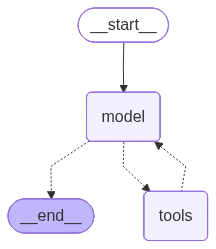

In [5]:
flight_agent

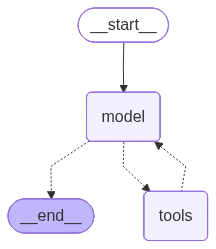

In [6]:
hotel_agent

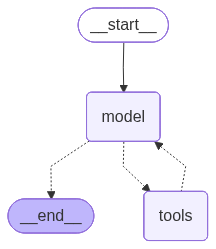

In [7]:
supervisor_agent

In [8]:
# Example 1
if __name__ == "__main__":
   user_request = (
       "Plan a 3-day trip to Singapore next month. "
       "Book a morning flight from Mumbai and reserve a hotel near Marina Bay."
   )

   print("\nUser Request:\n", user_request)
   print("\n" + "="*80 + "\n")

   for step in supervisor_agent.stream(
       {"messages": [{"role": "user", "content": user_request}]}
   ):
       for update in step.values():
           for message in update.get("messages", []):
               message.pretty_print()


User Request:
 Plan a 3-day trip to Singapore next month. Book a morning flight from Mumbai and reserve a hotel near Marina Bay.


================================== Ai Message ==================================

[{'type': 'text', 'text': "Okay, let's break this down into steps:"}, {'type': 'tool_use', 'name': 'arrange_flight', 'input': {'request': 'Book a morning flight from Mumbai to Singapore next month for a 3-day trip'}, 'id': 'tooluse_EEgQDHdv6bW6IFzAZfkzoG'}]
Tool Calls:
  arrange_flight (tooluse_EEgQDHdv6bW6IFzAZfkzoG)
 Call ID: tooluse_EEgQDHdv6bW6IFzAZfkzoG
  Args:
    request: Book a morning flight from Mumbai to Singapore next month for a 3-day trip
================================= Tool Message =================================
Name: arrange_flight

I have booked the SG202 flight from Mumbai to Singapore at 11:00 AM on June 1st for your 3-day trip next month. Please confirm if this booking looks good.
================================== Ai Message =========================

In [9]:
# Example 2

from rich import print

if __name__ == "__main__":
   user_request = (
       "Plan a 3-day trip to Malysia next month. "
       "Book a morning flight from Bangalore and reserve a hotel near City center."
   )

   print("\nUser Request:\n", user_request)
   print("\n" + "="*80 + "\n")

   for step in supervisor_agent.stream(
       {"messages": [{"role": "user", "content": user_request}]}
   ):
       for update in step.values():
           for message in update.get("messages", []):
               message.pretty_print()

User Request:
 Plan a 3-day trip to Malysia next month. Book a morning flight from Bangalore and reserve a hotel near City 
center.

================================================================================

================================== Ai Message ==================================

[{'type': 'text', 'text': "Okay, let's plan your 3-day trip to Malaysia next month."}, {'type': 'tool_use', 'name': 'arrange_flight', 'input': {'request': 'Book a morning flight from Bangalore to Kuala Lumpur, Malaysia for next month'}, 'id': 'tooluse_7C4uHNAI4D0EVN3lfdAPgf'}]
Tool Calls:
  arrange_flight (tooluse_7C4uHNAI4D0EVN3lfdAPgf)
 Call ID: tooluse_7C4uHNAI4D0EVN3lfdAPgf
  Args:
    request: Book a morning flight from Bangalore to Kuala Lumpur, Malaysia for next month
================================= Tool Message =================================
Name: arrange_flight

I have booked the SG202 flight from Bangalore to Kuala Lumpur at 11:00 AM next month for you. Please confirm if this booking works for your travel needs.
================================== Ai Message ==================================

[{'type': 'tool_use', 'name': 'arrange_hotel', 'input': {'request': 'Book a hotel near the city cen